# Atividade 4 — Análise exploratória da base de dados

**Disciplina:** Fundamentos de Inteligência Artificial — ADS/ULBRA  
**Projeto:** Academia — Recomendação de treinos e exercícios personalizados  
**Autor:** Vinicius Casagrande

Este notebook carrega a base simulada `dataset_academia.csv`, apresenta o dicionário de dados, calcula as estatísticas descritivas iniciais e gera duas visualizações. A limpeza e o tratamento aprofundado dos dados ficam para os Encontros 5 e 8, conforme orientado.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
df = pd.read_csv('dataset_academia.csv')
print('Formato (linhas, colunas):', df.shape)
df.head(10)

Formato (linhas, colunas): (300, 8)


,aluno_id,idade,objetivo,nivel_experiencia,dias_disponiveis_semana,restricao_fisica,equipamento_disponivel,treino_recomendado
0,1,32,Condicionamento,Avancado,2,Nenhuma,Completo,Treino C
1,2,37,Hipertrofia,Iniciante,4,Nenhuma,Completo,Treino A
2,3,24,Condicionamento,Iniciante,3,Lombar,Limitado,Treino D
3,4,31,Emagrecimento,Iniciante,4,Joelho,Nenhum,Treino D
4,5,22,Condicionamento,Intermediario,3,Nenhuma,Completo,Treino C
5,6,34,Hipertrofia,Avancado,3,Nenhuma,Completo,Treino A
6,7,17,Condicionamento,Iniciante,2,Nenhuma,Limitado,Treino C
7,8,34,Condicionamento,Avancado,4,Nenhuma,Completo,Treino C
8,9,23,Emagrecimento,Avancado,3,Nenhuma,Limitado,Treino B
9,10,33,Hipertrofia,Iniciante,4,Nenhuma,Completo,Treino A


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   aluno_id                 300 non-null    int64
 1   idade                    300 non-null    int64
 2   objetivo                 300 non-null    str  
 3   nivel_experiencia        300 non-null    str  
 4   dias_disponiveis_semana  300 non-null    int64
 5   restricao_fisica         300 non-null    str  
 6   equipamento_disponivel   300 non-null    str  
 7   treino_recomendado       300 non-null    str  
dtypes: int64(3), str(5)
memory usage: 18.9 KB


In [3]:
# Verificacao de valores ausentes e duplicados
print('Valores ausentes por coluna:')
print(df.isna().sum())
print()
print('Linhas duplicadas:', df.duplicated().sum())

Valores ausentes por coluna:
aluno_id                   0
idade                      0
objetivo                   0
nivel_experiencia          0
dias_disponiveis_semana    0
restricao_fisica           0
equipamento_disponivel     0
treino_recomendado         0
dtype: int64

Linhas duplicadas: 0


## Dicionário de dados

| Variável | Descrição | Tipo | Valores possíveis | Entrada/Saída |
|---|---|---|---|---|
| `aluno_id` | Identificador único do aluno simulado | Numérica discreta | 1 a 300 | — (não é feature) |
| `idade` | Idade do aluno em anos | Numérica contínua | 16 a 65 | Entrada |
| `objetivo` | Objetivo principal na academia | Categórica nominal | Emagrecimento, Hipertrofia, Condicionamento | Entrada |
| `nivel_experiencia` | Experiência com treino | Categórica ordinal | Iniciante, Intermediário, Avançado | Entrada |
| `dias_disponiveis_semana` | Dias por semana disponíveis para treinar | Numérica discreta | 1 a 6 | Entrada |
| `restricao_fisica` | Restrição física relevante | Categórica nominal | Nenhuma, Joelho, Ombro, Lombar | Entrada |
| `equipamento_disponivel` | Nível de acesso a equipamentos | Categórica ordinal | Completo, Limitado, Nenhum | Entrada |
| `treino_recomendado` | Categoria de treino recomendada | Categórica nominal | Treino A, B, C, D | **Saída (label)** |

Treino A = Musculação/Hipertrofia · Treino B = Cardio + Circuito · Treino C = Funcional · Treino D = Peso Corporal Adaptado.

## Estatísticas descritivas — variáveis numéricas

In [4]:
df[['idade', 'dias_disponiveis_semana']].describe().round(2)

,idade,dias_disponiveis_semana
count,300.00,300.00
mean,29.29,3.44
std,7.71,1.27
min,16.00,1.00
25%,23.00,3.00
50%,30.00,3.00
75%,35.00,4.00
max,51.00,6.00


## Estatísticas descritivas — variáveis categóricas

In [5]:
cat_cols = ['objetivo', 'nivel_experiencia', 'restricao_fisica',
            'equipamento_disponivel', 'treino_recomendado']
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- objetivo ---
objetivo
Hipertrofia        114
Emagrecimento      103
Condicionamento     83
Name: count, dtype: int64

--- nivel_experiencia ---
nivel_experiencia
Iniciante        161
Intermediario    100
Avancado          39
Name: count, dtype: int64

--- restricao_fisica ---
restricao_fisica
Nenhuma    208
Lombar      34
Joelho      34
Ombro       24
Name: count, dtype: int64

--- equipamento_disponivel ---
equipamento_disponivel
Completo    168
Limitado    110
Nenhum       22
Name: count, dtype: int64

--- treino_recomendado ---
treino_recomendado
Treino D    92
Treino C    80
Treino A    74
Treino B    54
Name: count, dtype: int64



## Visualização inicial

Duas visualizações: distribuição da idade dos alunos e contagem de treinos recomendados (variável-alvo).

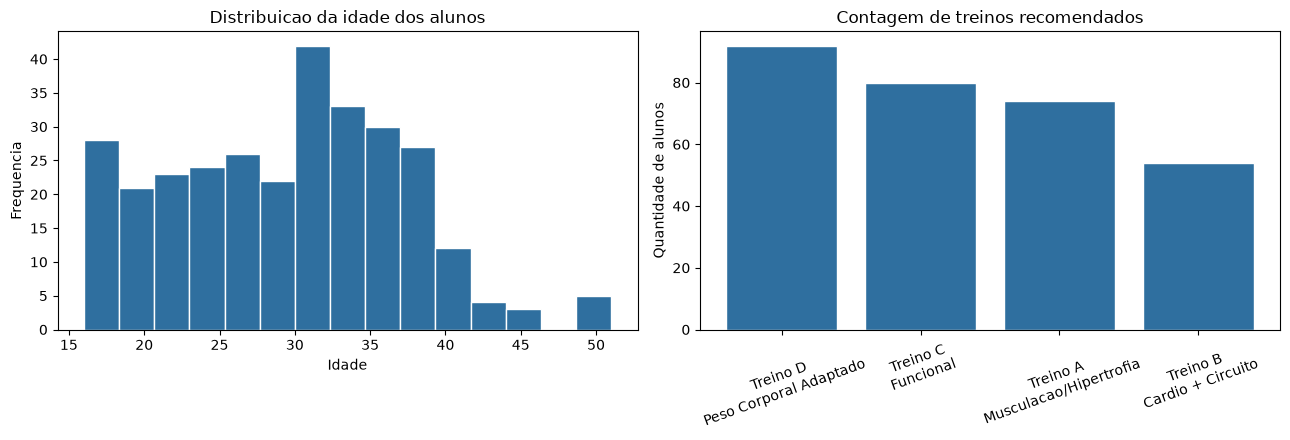

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['idade'], bins=15, color='#2f6f9f', edgecolor='white')
axes[0].set_title('Distribuicao da idade dos alunos')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequencia')

ordem = df['treino_recomendado'].value_counts().index
rotulos = {'Treino A': 'Treino A\nMusculacao/Hipertrofia',
           'Treino B': 'Treino B\nCardio + Circuito',
           'Treino C': 'Treino C\nFuncional',
           'Treino D': 'Treino D\nPeso Corporal Adaptado'}
contagens = df['treino_recomendado'].value_counts()
axes[1].bar([rotulos[o] for o in ordem], contagens.values,
            color='#2f6f9f', edgecolor='white')
axes[1].set_title('Contagem de treinos recomendados')
axes[1].set_ylabel('Quantidade de alunos')
axes[1].tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.savefig('grafico_analise_inicial.png', dpi=120, bbox_inches='tight')
plt.show()

## Primeiras observações sobre a base (ponto de partida para o Encontro 5)

- A base é 100% simulada — ainda não reflete o comportamento real de alunos, sendo esta a limitação mais relevante da etapa.
- Não há valores ausentes, mas isso é artificial (decorre da geração sintética) e não deve ser assumido quando dados reais forem incorporados.
- `dias_disponiveis_semana` está concentrada entre 3 e 4 dias, com poucos exemplos nos extremos (1 e 6) — pode ser necessário tratar esses casos na preparação dos dados.
- A limpeza mais aprofundada (outliers, normalização, codificação das variáveis categóricas para o modelo) não foi feita nesta etapa, conforme orientado, e fica para os Encontros 5 e 8.
- As quatro classes do label ficaram razoavelmente balanceadas, o que é favorável para o treinamento futuro do classificador (Árvore de Decisão, definida na Atividade 3).